In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Style global
sns.set_theme(style="whitegrid")

# Palette cohérente (style consulting / pro)
COLORS = {
    "primary": "#2E86AB",   # bleu principal
    "secondary": "#A23B72", # violet/rose élégant
    "accent": "#F18F01",    # orange (attention visuelle)
    "neutral": "#6C757D"    # gris
}

# Paramètres globaux matplotlib
plt.rcParams.update({
    "figure.figsize": (10,6),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.titleweight": "bold"
})

In [6]:
import pandas as pd

df = pd.read_csv("ecommerce_customer_behavior_dataset_v2.csv")
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

In [8]:
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,34.945745,447.901689,3.011379,69.788135,1277.438711,14.535633,9.003109,6.503607,3.899408
std,11.046855,722.319705,1.417027,240.704662,2358.436375,2.925524,2.259954,3.488787,1.128803
min,18.000000,5.050000,1.000000,0.000000,6.210000,4.000000,1.000000,1.000000,1.000000
25%,26.000000,73.260000,2.000000,0.000000,172.970000,13.000000,7.000000,4.000000,3.000000
50%,35.000000,174.680000,3.000000,0.000000,455.850000,15.000000,9.000000,6.000000,4.000000
75%,42.000000,494.570000,4.000000,32.710000,1267.750000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,26.000000,18.000000,25.000000,5.000000


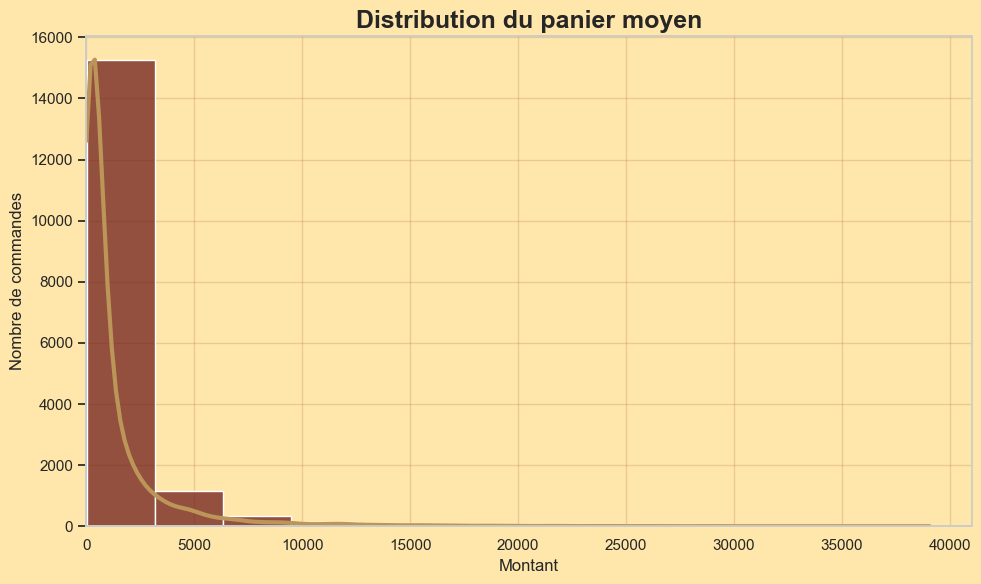

Total commandes : 17049
> 1000€ : 5113 (30.0%)
≤ 500€ : 8970 (52.6%)
Moyenne : 1277.44€
Médiane : 455.85€
Top 10% génèrent 53.4% du CA


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Palette
colors = {
    "primary": "#711D1B",
    "secondary": "#BC9558",
    "dark": "#442818",
    "accent": "#9B592A",
    "bg": "#FFE7AB"
}

# Figure + axe principal
fig, ax1 = plt.subplots(figsize=(10, 6))

# Fond
fig.patch.set_facecolor(colors["bg"])
ax1.set_facecolor(colors["bg"])

# Histogramme (gros blocs)
sns.histplot(
    data=df,
    x="Total_Amount",
    bins=12,
    color=colors["primary"],
    edgecolor="white",
    ax=ax1
)

# Axe secondaire pour la courbe
ax2 = ax1.twinx()

sns.kdeplot(
    data=df,
    x="Total_Amount",
    color=colors["secondary"],
    linewidth=3,
    bw_adjust=1.2,
    clip=(0, None),   # 🔥 empêche les valeurs < 0
    ax=ax2
)

# Nettoyage axe droit (pour rendu propre)
ax2.set_ylabel("")
ax2.set_yticks([])
ax2.spines["right"].set_visible(False)

# Titres
ax1.set_title("Distribution du panier moyen", fontsize=18, fontweight="bold")
ax1.set_xlabel("Montant")
ax1.set_ylabel("Nombre de commandes")

# Bloquer l'axe à 0
ax1.set_xlim(left=0)

# Grille propre
ax1.grid(color="#9B592A", alpha=0.2)

plt.tight_layout()
plt.show()
total_orders = len(df)

orders_above_1000 = (df["Total_Amount"] > 1000).sum()
pct_above_1000 = orders_above_1000 / total_orders * 100

orders_below_500 = (df["Total_Amount"] <= 500).sum()
pct_below_500 = orders_below_500 / total_orders * 100

mean_value = df["Total_Amount"].mean()
median_value = df["Total_Amount"].median()

print(f"Total commandes : {total_orders}")
print(f"> 1000€ : {orders_above_1000} ({pct_above_1000:.1f}%)")
print(f"≤ 500€ : {orders_below_500} ({pct_below_500:.1f}%)")
print(f"Moyenne : {mean_value:.2f}€")
print(f"Médiane : {median_value:.2f}€")
top_10_pct = df["Total_Amount"].quantile(0.9)

top_orders = df[df["Total_Amount"] >= top_10_pct]

share_revenue = top_orders["Total_Amount"].sum() / df["Total_Amount"].sum() * 100

print(f"Top 10% génèrent {share_revenue:.1f}% du CA")

In [42]:
df["Discount_Rate"] = df["Discount_Amount"] / (df["Unit_Price"] * df["Quantity"])

In [84]:
df.sort_values("Total_Amount", ascending=False).head(20)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Discount_Rate
12862,ORD_003795-1,CUST_03795,2023-02-06,35,Other,Ankara,Electronics,7570.41,5,0.00,37852.05,Credit Card,Mobile,13,5,True,7,5,0.000000
13247,ORD_003906-5,CUST_03906,2024-01-01,31,Male,Bursa,Electronics,7440.42,5,4378.57,32823.53,Digital Wallet,Mobile,8,8,True,17,5,0.117697
10483,ORD_003084-1,CUST_03084,2023-02-20,21,Female,Istanbul,Electronics,5809.07,5,0.00,29045.35,Bank Transfer,Mobile,14,10,True,9,3,0.000000
5451,ORD_001573-2,CUST_01573,2024-03-23,38,Male,Gaziantep,Electronics,5728.15,5,0.00,28640.75,Credit Card,Mobile,13,13,True,12,5,0.000000
10732,ORD_003149-5,CUST_03149,2023-09-08,33,Female,Istanbul,Electronics,6598.67,5,4354.49,28638.86,Cash on Delivery,Mobile,14,8,True,3,4,0.131981
10647,ORD_003128-1,CUST_03128,2023-08-06,50,Female,Istanbul,Electronics,5272.70,5,0.00,26363.50,Digital Wallet,Mobile,12,8,False,5,5,0.000000
16967,ORD_004975-2,CUST_04975,2023-03-07,18,Male,Antalya,Electronics,5201.05,5,0.00,26005.25,Bank Transfer,Mobile,10,11,True,5,3,0.000000
13552,ORD_003992-1,CUST_03992,2023-05-12,29,Male,Istanbul,Electronics,5115.88,5,0.00,25579.40,Digital Wallet,Mobile,19,9,False,2,5,0.000000
8429,ORD_002459-2,CUST_02459,2023-04-21,40,Male,Konya,Electronics,5112.42,5,0.00,25562.10,Credit Card,Desktop,22,8,True,5,3,0.000000
6238,ORD_001816-6,CUST_01816,2023-11-01,24,Female,Istanbul,Electronics,7900.01,4,6538.29,25061.75,Credit Card,Mobile,12,12,True,9,5,0.206908


In [46]:
import pandas as pd
import numpy as np

df_pie = df.copy()

# Sécuriser la variable
df_pie = df_pie[df_pie["Discount_Rate"].notna()].copy()

# Tranches de 5%
bins = [-0.001, 0.0001, 0.05, 0.10, 0.15, 0.20, 0.25]
labels = [
    "Sans réduc",
    "0-5%",
    "5-10%",
    "10-15%",
    "15-20%",
    "20-25%"
]

df_pie["Discount_Bin"] = pd.cut(
    df_pie["Discount_Rate"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

colors = {
    "primary": "#711D1B",
    "secondary": "#BC9558",
    "dark": "#442818",
    "accent": "#9B592A",
    "bg": "#FFE7AB"
}

df_analysis = df.copy()

# Paliers autorisés supposés
allowed_rates = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.25])

# Fonction pour ramener chaque taux au palier le plus proche
def nearest_rate(x, allowed=allowed_rates):
    return allowed[np.abs(allowed - x).argmin()]

df_analysis["Discount_Rate_Clean"] = df_analysis["Discount_Rate"].apply(nearest_rate)
df_analysis["Discount_Label"] = (df_analysis["Discount_Rate_Clean"] * 100).astype(int).astype(str) + "%"

# Vérification
print(df_analysis["Discount_Label"].value_counts().sort_index())

Discount_Label
0%     10572
10%     1901
15%     1930
20%     1702
5%       944
Name: count, dtype: int64


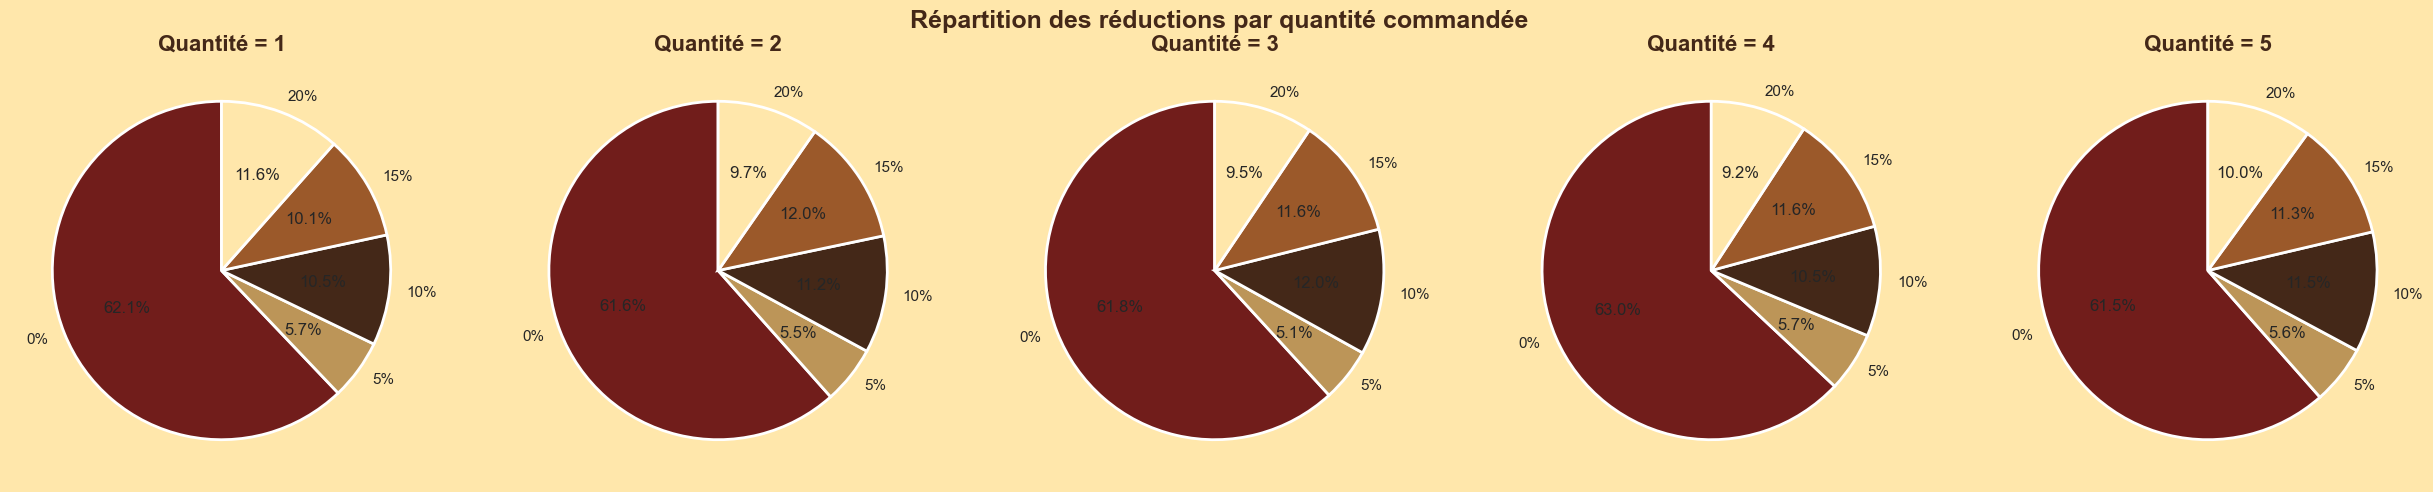

In [78]:
palette = ["#711D1B", "#BC9558", "#442818", "#9B592A", "#FFE7AB", "#C9A66B"]

quantities = sorted(df_analysis["Quantity"].unique())
order = ["0%", "5%", "10%", "15%", "20%", "25%"]

fig, axes = plt.subplots(1, len(quantities), figsize=(5 * len(quantities), 5))
fig.patch.set_facecolor(colors["bg"])

if len(quantities) == 1:
    axes = [axes]

for ax, q in zip(axes, quantities):
    ax.set_facecolor(colors["bg"])

    counts = (
        df_analysis[df_analysis["Quantity"] == q]["Discount_Label"]
        .value_counts()
        .reindex(order, fill_value=0)
    )

    counts_nonzero = counts[counts > 0]
    palette_nonzero = palette[:len(counts_nonzero)]

    ax.pie(
        counts_nonzero,
        labels=counts_nonzero.index,
        autopct=lambda p: f"{p:.1f}%",
        startangle=90,
        colors=palette_nonzero,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )

    ax.set_title(f"Quantité = {int(q)}", fontweight="bold", color=colors["dark"])

plt.suptitle(
    "Répartition des réductions par quantité commandée",
    fontsize=18,
    fontweight="bold",
    color=colors["dark"]
)

plt.tight_layout()
plt.show()

In [ ]:
df_analysis = df.copy()

bins = [-0.001, 0.0001, 0.05, 0.10, 0.15, 0.20, 0.25]
labels = ["Sans réduc", "0-5%", "5-10%", "10-15%", "15-20%", "20-25%"]

df_analysis["Discount_Bin"] = pd.cut(
    df_analysis["Discount_Rate"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

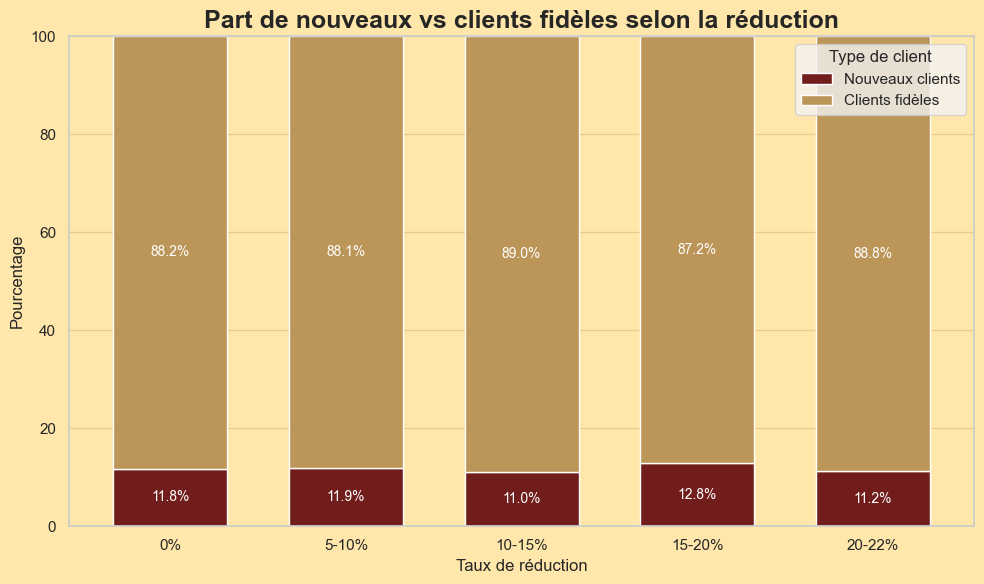

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

colors = {
    "primary": "#711D1B",
    "secondary": "#BC9558",
    "dark": "#442818",
    "accent": "#9B592A",
    "bg": "#FFE7AB"
}

df_analysis = df.copy()

# Regrouper les vraies réductions présentes dans la base
def label_discount(x):
    if x == 0:
        return "0%"
    elif 0 < x < 0.10:
        return "5-10%"
    elif 0.10 <= x < 0.15:
        return "10-15%"
    elif 0.15 <= x < 0.20:
        return "15-20%"
    else:
        return "20-22%"

df_analysis["Discount_Label"] = df_analysis["Discount_Rate"].apply(label_discount)

# Tableau en pourcentage
table = pd.crosstab(
    df_analysis["Discount_Label"],
    df_analysis["Is_Returning_Customer"],
    normalize="index"
) * 100

# Ordre logique
order = ["0%", "5-10%", "10-15%", "15-20%", "20-22%"]
table = table.reindex(order)

# Ici d'après ton print :
# True = clients fidèles
# False = nouveaux clients
table = table.rename(columns={False: "Nouveaux clients", True: "Clients fidèles"})

# Graphique
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

table.plot(
    kind="bar",
    stacked=True,
    color=[colors["primary"], colors["secondary"]],
    ax=ax,
    width=0.65
)

# Ajouter les % dans les barres
for container in ax.containers:
    labels = []
    for bar in container:
        h = bar.get_height()
        labels.append(f"{h:.1f}%" if h >= 4 else "")
    ax.bar_label(container, labels=labels, label_type="center", color="white", fontsize=10)

ax.set_title("Part de nouveaux vs clients fidèles selon la réduction", fontsize=18, fontweight="bold")
ax.set_xlabel("Taux de réduction")
ax.set_ylabel("Pourcentage")
ax.grid(axis="y", color=colors["accent"], alpha=0.2)
ax.legend(title="Type de client")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [64]:
df_analysis = df.copy()

df_analysis["Price_Bin"] = pd.qcut(df_analysis["Unit_Price"], 5)

In [65]:
price_qty = df_analysis.groupby("Price_Bin")["Quantity"].mean().reset_index()

C:\Users\German\AppData\Local\Temp\ipykernel_14704\3371447424.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_qty = df_analysis.groupby("Price_Bin")["Quantity"].mean().reset_index()


In [80]:
df_analysis = df.copy()

df_analysis["Price_Bin"] = pd.qcut(df_analysis["Unit_Price"], 5)

# transformer en labels simples
df_analysis["Price_Label"] = df_analysis["Price_Bin"].apply(
    lambda x: f"{int(x.left)} - {int(x.right)}"
)

In [81]:
price_qty = df_analysis.groupby("Price_Label")["Quantity"].mean().reset_index()

C:\Users\German\AppData\Local\Temp\ipykernel_14704\731959223.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_qty = df_analysis.groupby("Price_Label")["Quantity"].mean().reset_index()


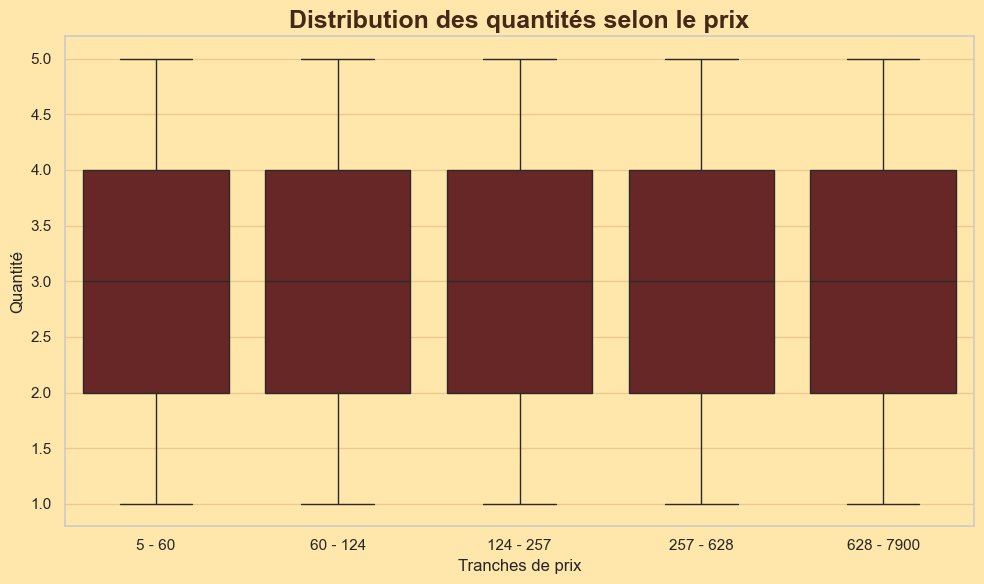

In [83]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

sns.boxplot(
    data=df_analysis,
    x="Price_Label",
    y="Quantity",
    color=colors["primary"]
)

ax.set_title("Distribution des quantités selon le prix", fontsize=18, fontweight="bold", color=colors["text"])
ax.set_xlabel("Tranches de prix")
ax.set_ylabel("Quantité")
ax.grid(axis="y", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()

In [67]:
ca_cat = df.groupby("Product_Category")["Total_Amount"].sum().sort_values()

In [68]:
avg_cat = df.groupby("Product_Category")["Total_Amount"].mean().sort_values()

In [69]:
ca_cat = (
    df.groupby("Product_Category")["Total_Amount"]
    .sum()
    .sort_values()
)

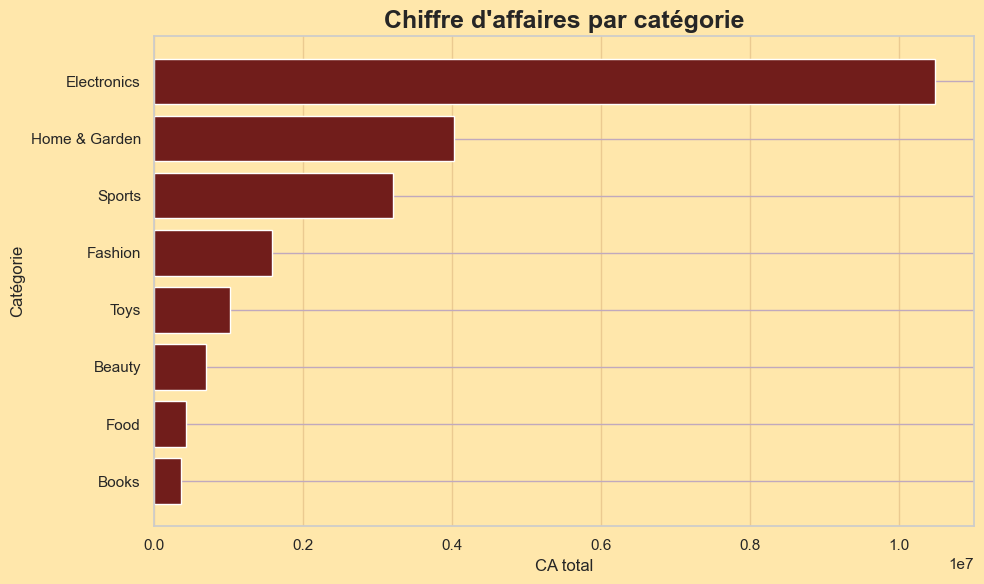

In [70]:
import matplotlib.pyplot as plt

colors = {
    "primary": "#711D1B",
    "secondary": "#BC9558",
    "dark": "#442818",
    "accent": "#9B592A",
    "bg": "#FFE7AB"
}

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

ax.barh(
    ca_cat.index,
    ca_cat.values,
    color=colors["primary"]
)

ax.set_title("Chiffre d'affaires par catégorie", fontsize=18, fontweight="bold")
ax.set_xlabel("CA total")
ax.set_ylabel("Catégorie")
ax.grid(axis="x", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()

In [71]:
avg_cat = (
    df.groupby("Product_Category")["Total_Amount"]
    .mean()
    .sort_values()
)

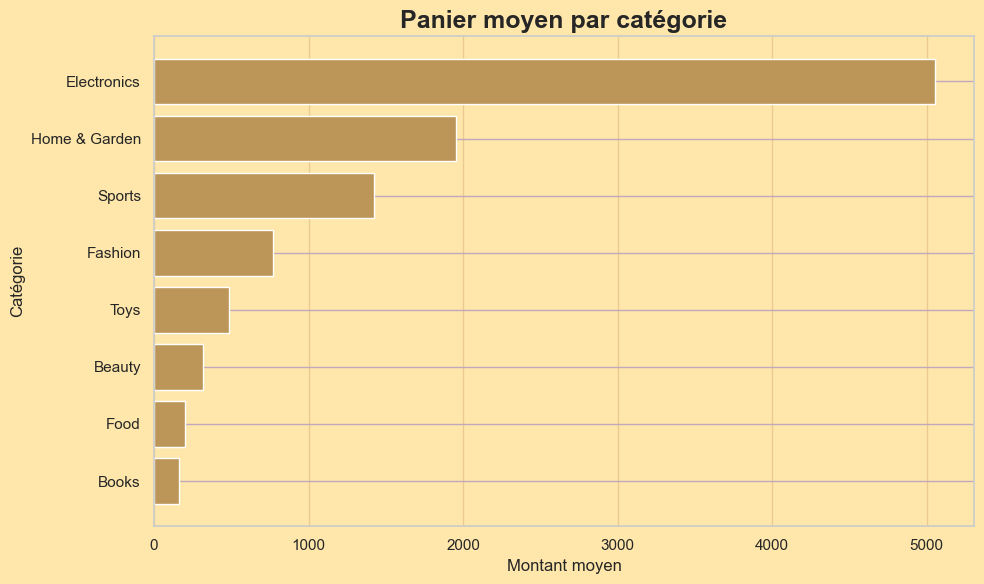

In [72]:
fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

ax.barh(
    avg_cat.index,
    avg_cat.values,
    color=colors["secondary"]
)

ax.set_title("Panier moyen par catégorie", fontsize=18, fontweight="bold")
ax.set_xlabel("Montant moyen")
ax.set_ylabel("Catégorie")
ax.grid(axis="x", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()

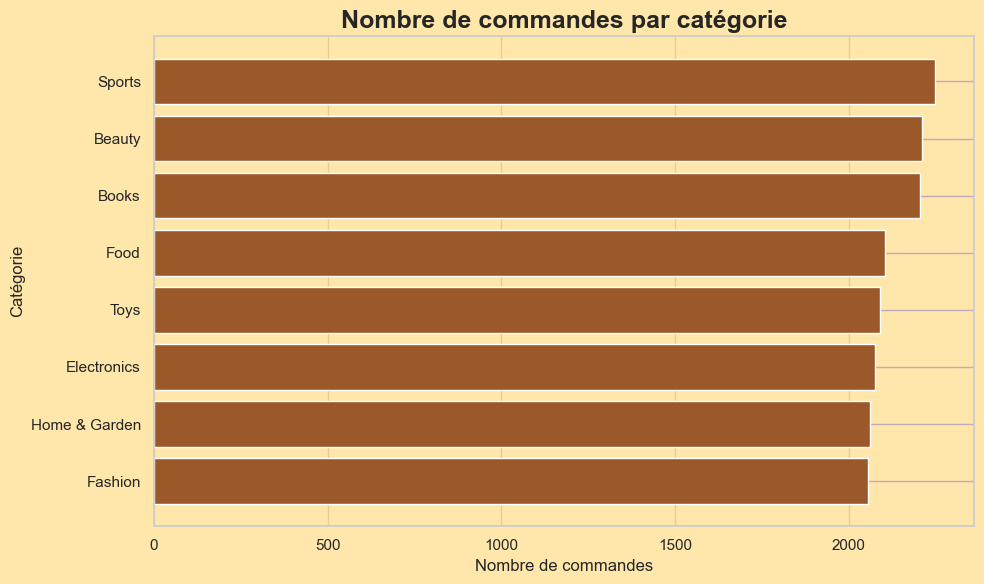

In [73]:
count_cat = df["Product_Category"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

ax.barh(
    count_cat.index,
    count_cat.values,
    color=colors["accent"]
)

ax.set_title("Nombre de commandes par catégorie", fontsize=18, fontweight="bold")
ax.set_xlabel("Nombre de commandes")
ax.set_ylabel("Catégorie")
ax.grid(axis="x", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()

In [85]:
df_analysis = df.copy()

df_analysis["Age_Group"] = pd.cut(
    df_analysis["Age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "25-35", "35-45", "45-55", "55-65"]
)

In [86]:
age_cat = (
    df_analysis
    .groupby(["Age_Group", "Product_Category"])["Quantity"]
    .mean()
    .reset_index()
)

C:\Users\German\AppData\Local\Temp\ipykernel_14704\4134378026.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Age_Group", "Product_Category"])["Quantity"]


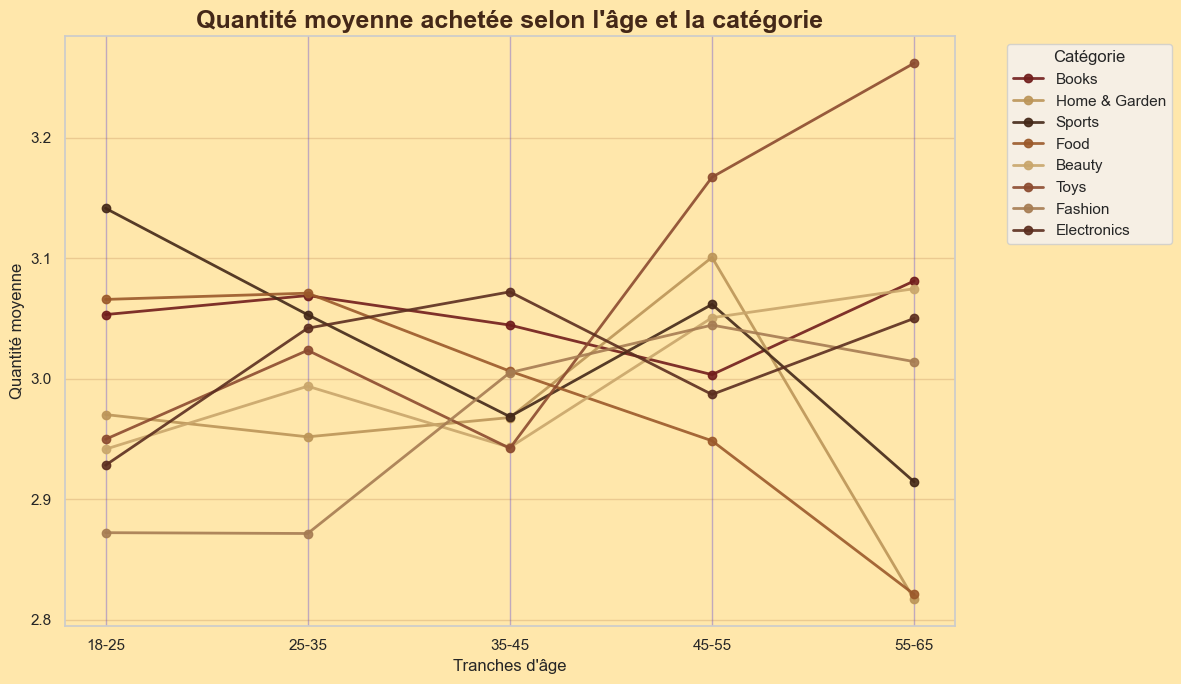

In [88]:
import matplotlib.pyplot as plt

colors = {
    "palette": ["#711D1B", "#BC9558", "#442818", "#9B592A", "#C9A66B", "#8C4B2F", "#A67C52", "#5C2E1F"],
    "bg": "#FFE7AB",
    "text": "#442818",
    "grid": "#9B592A"
}

categories = df_analysis["Product_Category"].unique()

fig, ax = plt.subplots(figsize=(12,7))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

for i, cat in enumerate(categories):
    data = age_cat[age_cat["Product_Category"] == cat]
    
    ax.plot(
        data["Age_Group"],
        data["Quantity"],
        marker="o",
        label=cat,
        color=colors["palette"][i % len(colors["palette"])],
        linewidth=2,
        alpha=0.9
    )

ax.set_title(
    "Quantité moyenne achetée selon l'âge et la catégorie",
    fontsize=18,
    fontweight="bold",
    color=colors["text"]
)

ax.set_xlabel("Tranches d'âge")
ax.set_ylabel("Quantité moyenne")
ax.grid(axis="y", color=colors["grid"], alpha=0.2)

ax.legend(title="Catégorie", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [89]:
import matplotlib.colors as mcolors

def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - x) * (1 - amount) for x in c)

In [90]:
base_colors = ["#711D1B", "#BC9558", "#442818", "#9B592A"]

extended_palette = []

for color in base_colors:
    extended_palette.append(color)                     # original
    extended_palette.append(lighten_color(color, 0.3)) # plus clair

# maintenant tu as 8 couleurs

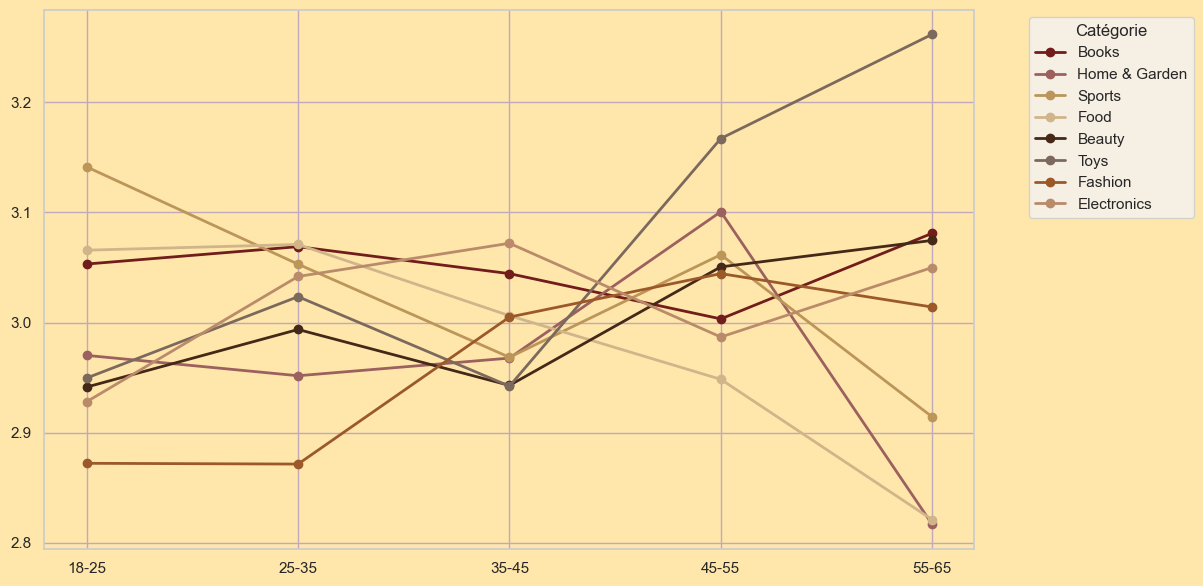

In [91]:
categories = df_analysis["Product_Category"].unique()

fig, ax = plt.subplots(figsize=(12,7))
fig.patch.set_facecolor("#FFE7AB")
ax.set_facecolor("#FFE7AB")

for i, cat in enumerate(categories):
    data = age_cat[age_cat["Product_Category"] == cat]
    
    ax.plot(
        data["Age_Group"],
        data["Quantity"],
        marker="o",
        label=cat,
        color=extended_palette[i],
        linewidth=2
    )

ax.legend(title="Catégorie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

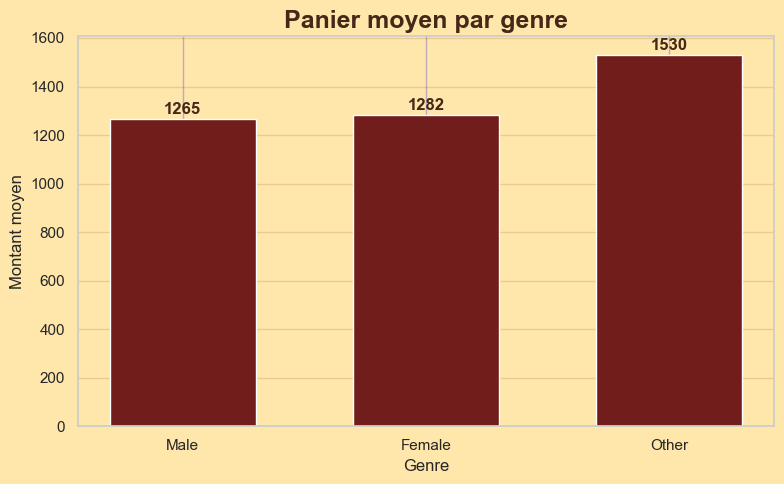

In [102]:
import matplotlib.pyplot as plt

colors = {
    "primary": "#711D1B",
    "secondary": "#BC9558",
    "dark": "#442818",
    "accent": "#9B592A",
    "bg": "#FFE7AB"
}

gender_basket = (
    df.groupby("Gender")["Total_Amount"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

bars = ax.bar(
    gender_basket.index,
    gender_basket.values,
    color=colors["primary"],
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 20,
        f"{h:.0f}",
        ha="center",
        color=colors["dark"],
        fontweight="bold"
    )

ax.set_title("Panier moyen par genre", fontsize=18, fontweight="bold", color=colors["dark"])
ax.set_xlabel("Genre")
ax.set_ylabel("Montant moyen")
ax.grid(axis="y", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()

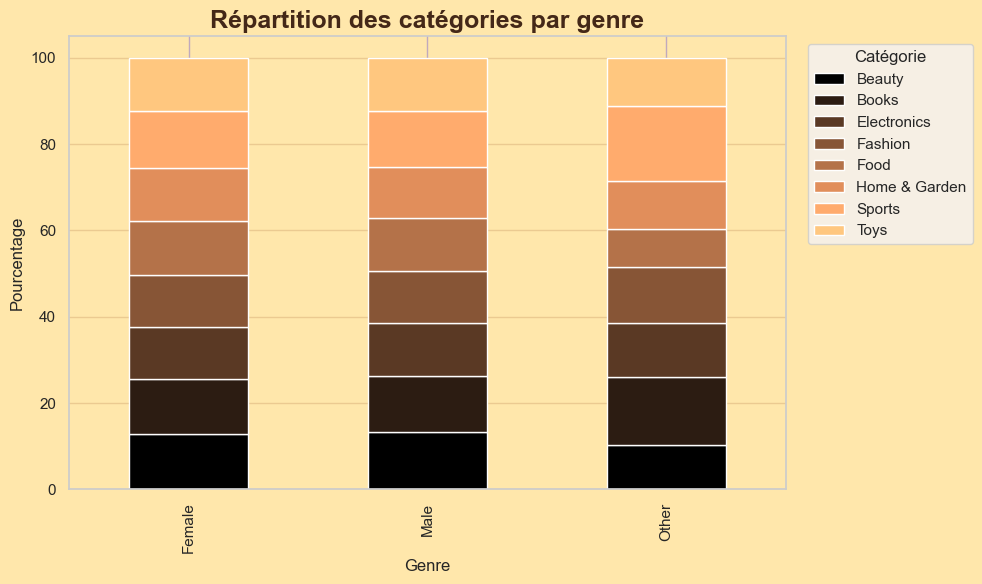

In [93]:
gender_cat = pd.crosstab(df["Gender"], df["Product_Category"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

gender_cat.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="copper"
)

ax.set_title("Répartition des catégories par genre", fontsize=18, fontweight="bold", color=colors["dark"])
ax.set_xlabel("Genre")
ax.set_ylabel("Pourcentage")
ax.grid(axis="y", color=colors["accent"], alpha=0.2)
ax.legend(title="Catégorie", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

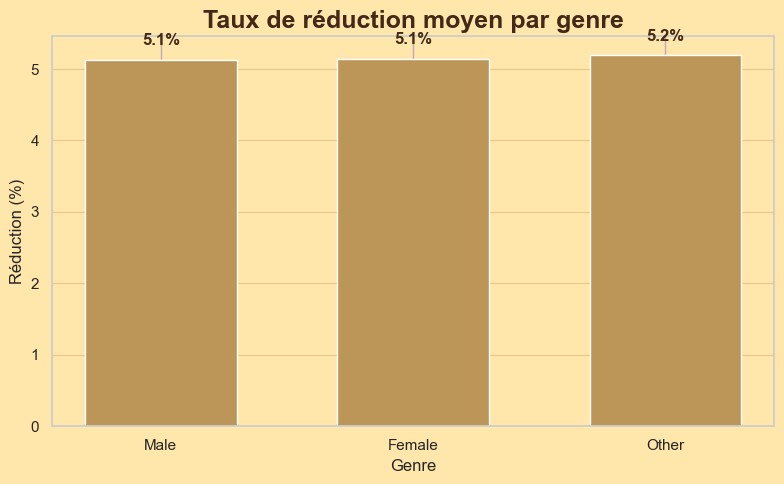

In [95]:
gender_discount_rate = (
    df.groupby("Gender")["Discount_Rate"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

bars = ax.bar(
    gender_discount_rate.index,
    gender_discount_rate.values * 100,
    color=colors["secondary"],
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.2,
        f"{h:.1f}%",
        ha="center",
        color=colors["dark"],
        fontweight="bold"
    )

ax.set_title("Taux de réduction moyen par genre", fontsize=18, fontweight="bold", color=colors["dark"])
ax.set_xlabel("Genre")
ax.set_ylabel("Réduction (%)")
ax.grid(axis="y", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()

In [98]:
top_n = 7

city_ca = df.groupby("City")["Total_Amount"].sum()

top_cities = city_ca.sort_values(ascending=False).head(top_n)

In [99]:
others = city_ca.sum() - top_cities.sum()

top_cities["Autres"] = others

In [100]:
top_cities = top_cities.sort_values()

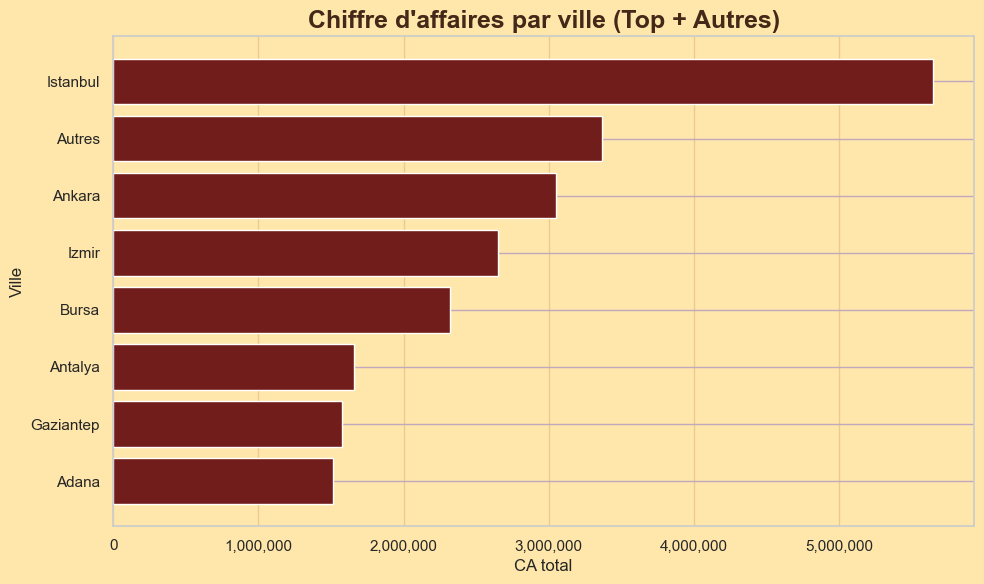

In [101]:
fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

ax.barh(
    top_cities.index,
    top_cities.values,
    color=colors["primary"]
)

ax.set_title("Chiffre d'affaires par ville (Top + Autres)", fontsize=18, fontweight="bold", color=colors["dark"])
ax.set_xlabel("CA total")
ax.set_ylabel("Ville")
ax.grid(axis="x", color=colors["accent"], alpha=0.2)

from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

In [103]:
df_analysis = df.copy()

df_analysis["Delivery_Group"] = pd.cut(
    df_analysis["Delivery_Time_Days"],
    bins=[0, 2, 4, 6, 8, 10],
    labels=["1-2j", "3-4j", "5-6j", "7-8j", "9-10j"]
)

C:\Users\German\AppData\Local\Temp\ipykernel_14704\1740352686.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby("Delivery_Group")["Customer_Rating"]


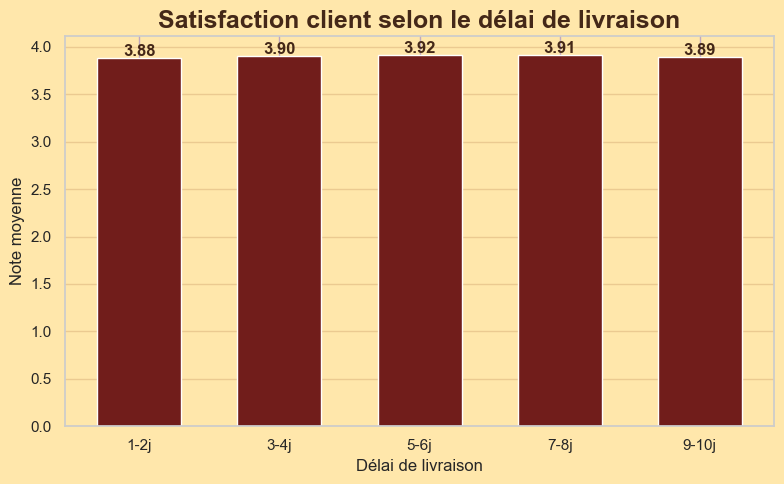

In [104]:
rating_delivery = (
    df_analysis.groupby("Delivery_Group")["Customer_Rating"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

bars = ax.bar(
    rating_delivery["Delivery_Group"],
    rating_delivery["Customer_Rating"],
    color=colors["primary"],
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.02,
        f"{h:.2f}",
        ha="center",
        color=colors["dark"],
        fontweight="bold"
    )

ax.set_title("Satisfaction client selon le délai de livraison",
             fontsize=18, fontweight="bold", color=colors["dark"])

ax.set_xlabel("Délai de livraison")
ax.set_ylabel("Note moyenne")
ax.grid(axis="y", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()

In [105]:
df_analysis["Session_Group"] = pd.cut(
    df_analysis["Session_Duration_Minutes"],
    bins=[0, 5, 10, 15, 20, 30],
    labels=["0-5", "5-10", "10-15", "15-20", "20+"]
)

C:\Users\German\AppData\Local\Temp\ipykernel_14704\3464457357.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby("Session_Group")["Total_Amount"]


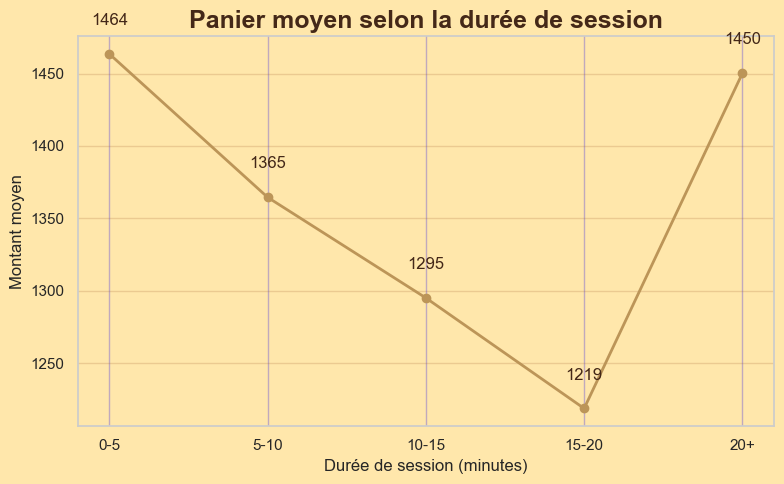

In [106]:
session_amount = (
    df_analysis.groupby("Session_Group")["Total_Amount"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

ax.plot(
    session_amount["Session_Group"],
    session_amount["Total_Amount"],
    marker="o",
    color=colors["secondary"],
    linewidth=2
)

for i, val in enumerate(session_amount["Total_Amount"]):
    ax.text(i, val + 20, f"{val:.0f}", ha="center", color=colors["dark"])

ax.set_title("Panier moyen selon la durée de session",
             fontsize=18, fontweight="bold", color=colors["dark"])

ax.set_xlabel("Durée de session (minutes)")
ax.set_ylabel("Montant moyen")
ax.grid(axis="y", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()

C:\Users\German\AppData\Local\Temp\ipykernel_14704\4216478629.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby("Pages_Group")["Total_Amount"]


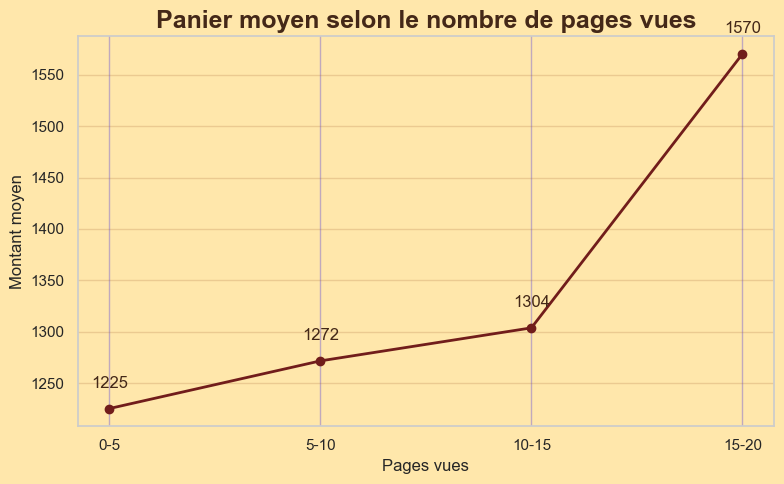

In [107]:
df_analysis["Pages_Group"] = pd.cut(
    df_analysis["Pages_Viewed"],
    bins=[0, 5, 10, 15, 20],
    labels=["0-5", "5-10", "10-15", "15-20"]
)

pages_amount = (
    df_analysis.groupby("Pages_Group")["Total_Amount"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

ax.plot(
    pages_amount["Pages_Group"],
    pages_amount["Total_Amount"],
    marker="o",
    color=colors["primary"],
    linewidth=2
)

for i, val in enumerate(pages_amount["Total_Amount"]):
    ax.text(i, val + 20, f"{val:.0f}", ha="center", color=colors["dark"])

ax.set_title("Panier moyen selon le nombre de pages vues",
             fontsize=18, fontweight="bold", color=colors["dark"])

ax.set_xlabel("Pages vues")
ax.set_ylabel("Montant moyen")
ax.grid(axis="y", color=colors["accent"], alpha=0.2)

plt.tight_layout()
plt.show()